In [ ]:
# LAB 8 - SERII DE TIMP 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

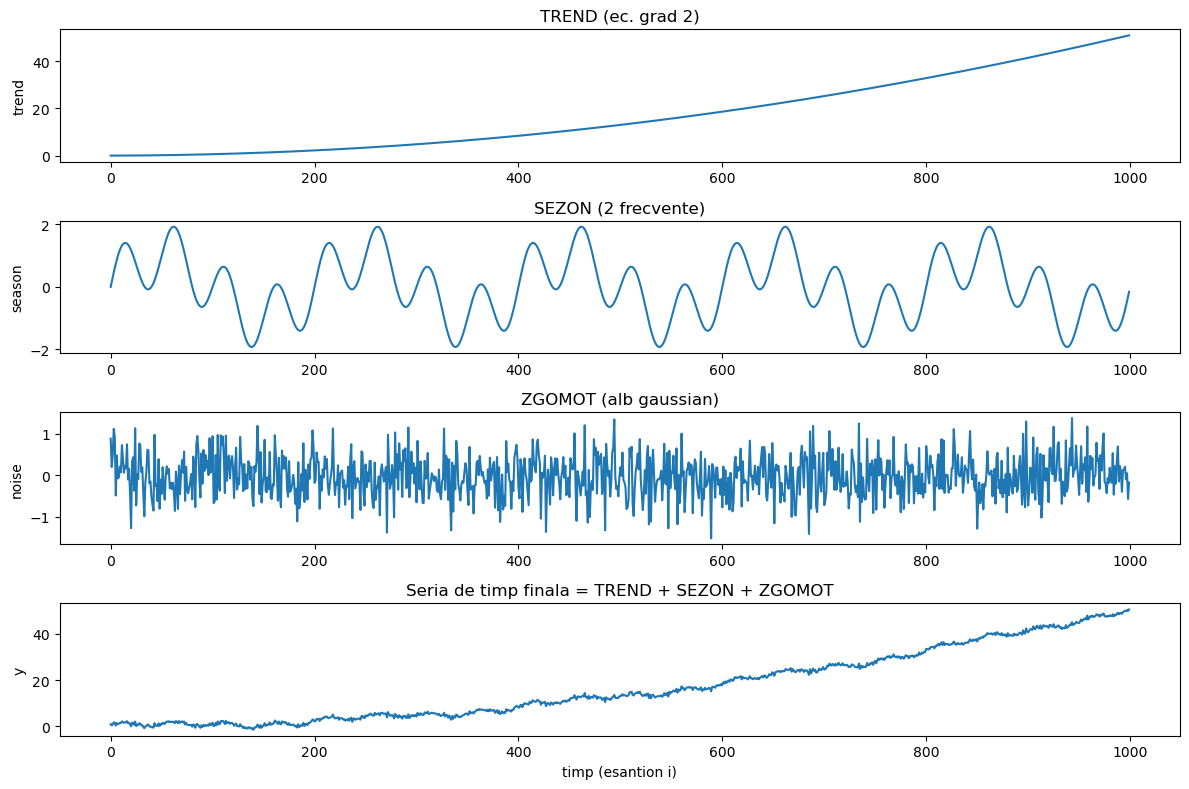

In [ ]:
#1a)

# generez o serie de timp N=1000 ca suma a trei componente:

# trend = o ec de gr 2
# sezon = 2 frecvente
# variatiile mici = zgomot alb gaussian

# Desenez seria de timp si cele 3 componente separat

N = 1000
t = np.arange(N) #momentele de timp 0, 1, ..., 999

# TREND (polinom de grad 2)
a, b, c = 0.00005, 1e-3, 0
trend = a * t ** 2 + b * t + c

#  SEZON
T1 = 50 # din 50 in 50 de esantioane
f1 = 1/T1
T2 = 200 # din 200 in 200
f2 = 1/T2
season =  np.sin(2 * np.pi *f1* t) + np.sin(2 * np.pi * f2*t )

# ZGOMOT
np.random.seed(0)   # ca să iasă la fel de fiecare dată
sigma = 0.5
noise = np.random.normal(0, sigma, size=N)

# SERIA DE TIMP = TREND + SESON + ZGOMOT
y = trend + season + noise

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, trend)
plt.title("TREND (ec. grad 2)")
plt.ylabel("trend")

plt.subplot(4, 1, 2)
plt.plot(t, season)
plt.title("SEZON (2 frecvente)")
plt.ylabel("season")

plt.subplot(4, 1, 3)
plt.plot(t, noise)
plt.title("ZGOMOT (alb gaussian)")
plt.ylabel("noise")

plt.subplot(4, 1, 4)
plt.plot(t, y)
plt.title("Seria de timp finala = TREND + SEZON + ZGOMOT")
plt.ylabel("y")
plt.xlabel("timp (esantion i)")

plt.tight_layout()
plt.savefig("1a.pdf")
plt.show()

In [ ]:
# b 
# vectorul de autocorelatie pentru seria de timp generata
# functie numpy care sa calculeze aceasta cantitate? de unde vine aceasta cantitate?
# desenez vectorul de autocorelatie



# VECTORUL DE AUTO-CORELATIE:

# gamma = [ gamma1, gamma2, gamma3, ....], unde:

#       gamma_i = SUMA dupa j de la    j = i-m -> i    din y[j]*y[j-t]
#   
#               = y[i]*y[i- t] + y[i-1]*y[i-1 - t] + y[i-2] * y[i-2 - t] + ... + y[i-m]*y[i-m - t]

# Este produsul scalar dintre ultimele m valori succesive ale seriei de timp       si       m valori succesive ale seriei de timp de acum t momente de timp

# E corelatia dintre ce se intampla acum in seria de timp si ce s-a intamplat in trecut in seria de timp, luand in considerare secvente de lungime m din serie

# gamma_t masoara cat de mult seama seria cu versiunea ei decalata cu t pasi



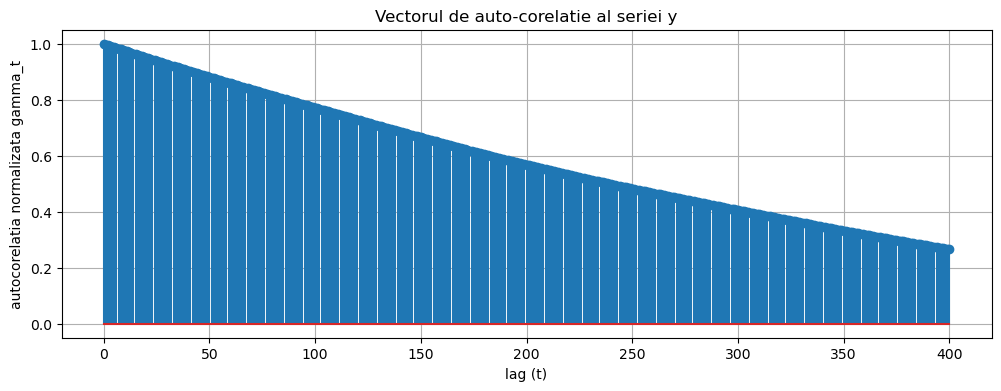

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = len(y)

max_lag = 400

gamma = np.zeros(max_lag+1)

for t in range( max_lag + 1):
    if t == 0: 
        gamma[t] = np.sum(y * y)
    else:
        gamma[t] = np.sum(y[t:] * y[:-t])     # prod scalar intre ultimele N-t valori ale seriei de timp si primele N-t valori ale seriei de timp
                                            # adica: corelatia seriei de timp cu seria de timp decalata in trecut cu t pozitii

# gamma[0] = corelatia seriei de timp cu ea insasi pe ultimele N-t = N-0 = N pozitii, adica corelatia seriei cu ea insasi de la inceput pana la final

# normalizez pt ca gamma[0] = 1
gamma_norm = gamma / gamma[0]


lags = np.arange(max_lag + 1)

plt.figure(figsize=(12,4))
plt.stem(lags, gamma_norm)
plt.xlabel("lag (t)")
plt.ylabel("autocorelatia normalizata gamma_t")
plt.title("Vectorul de auto-corelatie al seriei y")
plt.grid(True)
plt.savefig("1b_vectorul_de_autocorelatie.pdf")
plt.show()


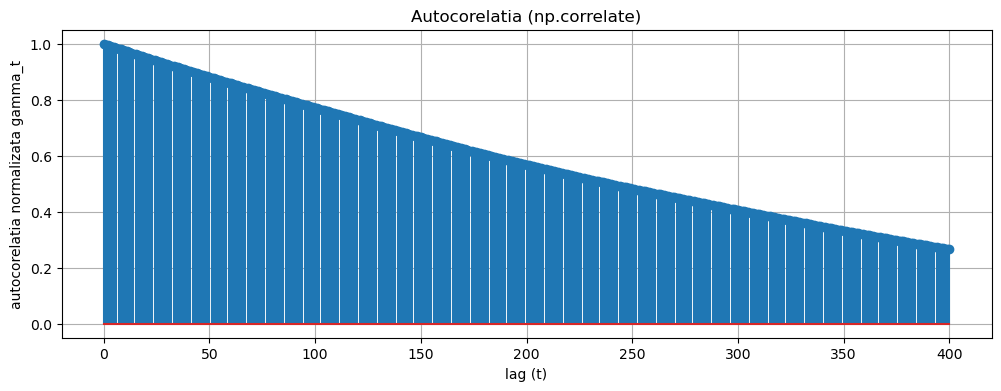

In [19]:
# auto-corelatia folosind np.correlate

# Despre np.correlate(a, b, mode = "full")
# calculeaza corelatia intre vectorii a si b pentru toate lag-urile (intarzierile/decalajele) posibile:

#-lag-uri negative <=> b deplasat inainte 
#-         0       <=> aliniere perfecta intre a si b
#-        pozitive <=> b deplasat inapoi fata de a

#np.correlate(y, y, full)
#     returneaza un vector de lungime 2N-1 reprezentand vectorul corelatiilor

# elementele din stanga din acest vector al corelatiilor = corelatiile cu lag negativ <=> valori din trecut ale lui y corelate cu valori din prezent
#                mijloc                                  = corelatia cu lag 0 <=> corelatia (ccare e maxima) dintre y si el insusi
#                dreapta                                 = corelatiile cu lag pozitiv <=> valori din prezent ale lui y versus valori din trecut = ce imi trebuie mie in vectorul de auto-corelatie

corr_full = np.correlate(y, y, mode='full')

# centrul vectorului ( lag = 0) este la pozitia N-1
mid = len(corr_full) // 2

# pastrez doar lag-urile pozitive 0,1,...,max_lag
gamma_cu_np = corr_full[mid : mid + max_lag + 1]

gamma_cu_np_norm = gamma_cu_np / gamma_cu_np[0]

plt.figure(figsize=(12,4))
plt.stem(np.arange(max_lag + 1), gamma_cu_np_norm)
plt.xlabel("lag (t)")
plt.ylabel("autocorelatia normalizata gamma_t")
plt.title("Autocorelatia (np.correlate)")
plt.grid(True)
plt.show()


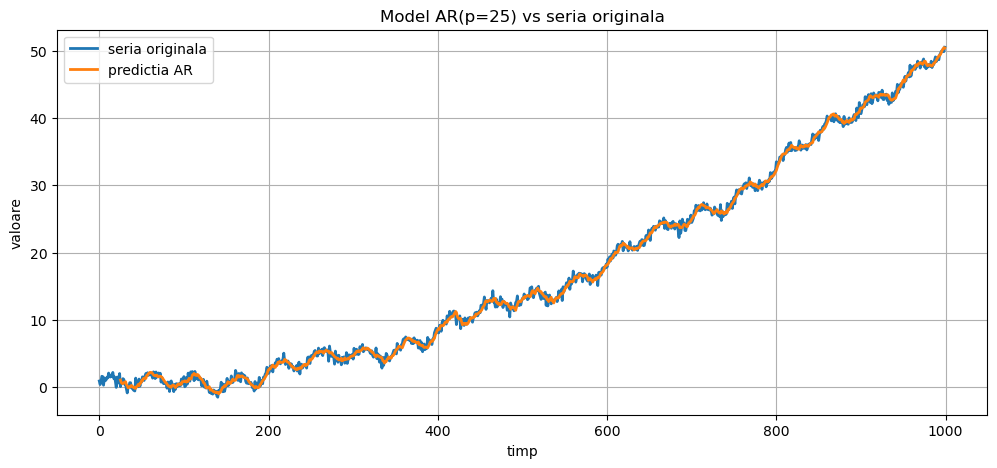

In [24]:
# c 
# un model AR de dimensiune p pentru seria de timp

# Predictia modelului este:
# y_hat[i+1] = x1 * y[i] + x2 * y[i-1] + x_p * y[i-p+1]

# Adica:
# y_hat[i+1] = x* transpus    x     y[i:i-p:-1]

#Cum aflu parametrii x1, x2, ... , x_p? (adica x*)

# x* = (Ytranspus Y)^-1     x    Ytranspus y


p = 25

Y = np.zeros((N - p, p)) # matricea care contine pe linii:
                                                
                                                # [ y[i-1], y[i-2], y[i-3],..., y[i-p]   ]       |
                                                # [ y[i-2], y[i-3], y[i-4],..., y[i-p-1] ]       |    N-p linii
                                                #        .........                               |
                                                
                                                        # p coloane

for i in range(p, N):
    Y[i - p, :] = y[i-p:i][::-1]   # vectorul [y[i-1], y[i-2], ..., y[i-p]]
    
            # y[i-p:i] = valorile din y de la pozitia i-p pana la i-1
            #         [::-1] =? le inversez si obtin vectorul cu valorile din y de la i-1 la i-p
            
            # aceste valori le pun in matricea Y pe linia i-p


y_target = y[p:] # vectorul cu valorile reale ale seriei de timp incepand cu pozitia p -> final
                    # pot face predictii doar incepand cu pozitia p, pt ca am nevoie de primele p valori (de la 0 la p-1) pentru a face predictia pozitiei p

x = np.linalg.inv(Y.T @ Y) @ (Y.T @ y_target)

#print("coef AR:", x)

y_pred = Y @ x #predictiile pentru pozitiile p -> N-1

plt.figure(figsize=(12,5))

plt.plot(y, label="seria originala", linewidth=2)
plt.plot(np.arange(p, N), y_pred, label="predictia AR", linewidth=2)

plt.title(f"Model AR(p={p}) vs seria originala")
plt.xlabel("timp")
plt.ylabel("valoare")
plt.legend()
plt.grid(True)
plt.savefig("1c.pdf")
plt.show()


Cel mai bun p = 92
Cel mai bun m = 1
MSE = 0.2500710784997415


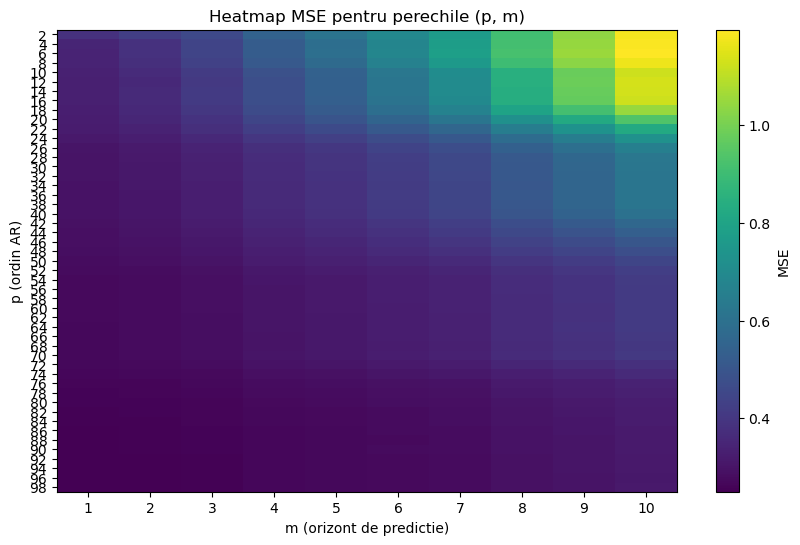

: 

In [ ]:
# d
# vreau sa prezic un singur pas din viitor.
# care e orizontul de timp m (din trecut) si care e p (dimensiunea modelului AR) care ofera cea mai buna predictie?



def fit_ar(y, p): # imi da coeficientii modelului pentru un anumit p setat
    N = len(y)
    Y = np.zeros((N - p, p))
    for i in range(p, N):
        Y[i - p] = y[i-p:i][::-1]
    y_target = y[p:]
    x = np.linalg.inv(Y.T @ Y) @ (Y.T @ y_target)
    return x


# y[0] y[1] ......................... y[N-1] | y_hat[N] y_hat[N+1] ..... y_hat[N-1 + m-1] y_hat[N-1 + m]
#                             |---------------------------------------------------------|
#                                      p pozitii pt a o prezice pe urmatoarea
def predict_m_steps(y, x, p, m):
    history = list(y[-p:])                      # ultimele p valori din seria de timp y
    for i in range(m):
        next_value = np.dot(x, history[::-1]) # prezic urmatoarea valoare, y_hat[N], cu ajutorul ultimelor p valori reale din y pe care le am
                                                # apoi o prezic pe urmatoarea, y_hat[N+1], cu ajutorul a p-1 valori reale din seria y si cu predictia anterioara
                                                # si tot asa pana ajung la
                                                # a prezice valoarea y_hat[m] cu ajutorul a:
                                                #               [(N-1 + m - 1) - (N) + 1] = m-1 valori prezise anterior si a 
                                                #               p-(m-1) valori reale din serie 
                                                #                   (ultimele din seria stiuta la care mai pot ajunge in cadrul 
                                                #                   celor p pozitii la care ma uit in spate pentru a face predictia)
        history.append(next_value)
        history.pop(0)
    return history[-1]          # returneaza predictia y_hat[N-1+m]

#Obs: in functia de mai sus indexarea interna se face 

def mse(a, b):
    return np.mean((a - b)**2)

p_values = range(2, 100, 2) #intervalele in care caut cele mai bune p si m    #p = lungimea secventei din serie pe care ma bazez ca sa fac predictia
m_values = range(1, 11)                                                     #m = peste cate pozitii in viitor vreau sa fac predictia

best_mse = float("inf")
best_p = None
best_m = None

N = len(y)

mse_matrix = np.zeros((len(p_values), len(m_values)))

for index_p, p in enumerate(p_values): #iau la rand valorile de p posibile
    x = fit_ar(y, p) #calculez x* al modelului pentru p-ul curent

    for index_m, m in enumerate(m_values): #apoi iau la rand fiecare orizont de timp m = 1, 2, ... momente de timp in viitor
        preds = []
        ground_truth = []

        for t in range(p, N - m): #pentru fiecare moment posibil de timp t care poate reprezenta capatul din dreapta al secventei de m valori pe baza carora fac predictia
            past = y[t-p:t]       #trecutul pe care il iau in considerare e de la t-p la t-1
            true = y[t-1 + m]        #iar predictia o fac pentru pozitia t-1 + m, deci vad cine e ground-truth-ul pe pozitia aia si o salvez in variabila "true"
            pred = predict_m_steps(past, x, p, m)
            preds.append(pred)            #adaug predictia pentru pozitia t-1+m la vectorul cu predictiile de peste m pozitii pentru toate subseriile consecutive de p elemente posibile
            ground_truth.append(true)       #iar ground-truth-ul curent la vectorul cu toate ground-truth-urile

        current_mse = mse(np.array(preds), np.array(ground_truth)) # mse pe cei doi vectori de predictii si gts
        mse_matrix[index_p, index_m] = mse(np.array(preds), np.array(ground_truth))
        
        if current_mse < best_mse: 
            best_mse = current_mse
            best_p = p
            best_m = m # aleg (p,m) care dau mse minim

print("Cel mai bun p =", best_p)
print("Cel mai bun m =", best_m)
print("MSE =", best_mse)


plt.figure(figsize=(10, 6))
plt.imshow(mse_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='MSE')
plt.xlabel('m (orizont de predictie)')
plt.ylabel('p (ordin AR)')
plt.title('Heatmap MSE pentru perechile (p, m)')

plt.xticks(ticks=np.arange(len(m_values)), labels=list(m_values))
plt.yticks(ticks=np.arange(len(p_values)), labels=list(p_values))

plt.show()